## 1. Load and validate the canonical historical schedule


In [1]:
import sys
from pathlib import Path
import hashlib
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.insert(0, "..")  
from common_metrics import require, fairness_metrics, gini

DATA_DIR = Path("output")  


def resolve_canonical():
    for candidate in [DATA_DIR / "canonical_schedule.csv", Path("canonical_schedule.csv")]:
        if candidate.is_file():
            return candidate
    raise FileNotFoundError("Could not find canonical_schedule.csv. Run notebook 00 first.")


canonical_path = resolve_canonical()
canonical_sha256 = hashlib.sha256(canonical_path.read_bytes()).hexdigest()
schedule = pd.read_csv(canonical_path)

required_columns = {
    "source_row", "week_id", "week_start", "week_end", "nT", "rotation_group",
    "rotation_round", "pharmacy_id", "location_id", "shift_type", "access_mode",
}
require(required_columns.issubset(schedule.columns), "Canonical schema is incomplete.")
schedule["week_start"] = pd.to_datetime(schedule["week_start"], errors="raise")
schedule["week_end"] = pd.to_datetime(schedule["week_end"], errors="raise")
for column in ["source_row", "nT", "rotation_group", "rotation_round"]:
    schedule[column] = pd.to_numeric(schedule[column], errors="raise").astype(int)
require(schedule["shift_type"].isin(["H24", "STANDARD"]).all(), "Invalid shift type.")
require(schedule["access_mode"].isin(["P", "C"]).all(), "Invalid access mode.")

week_fields = ["week_start", "week_end", "nT", "rotation_group", "rotation_round"]
require((schedule.groupby("week_id")[week_fields].nunique() == 1).all().all(), "Inconsistent week fields.")
weeks = schedule[["week_id"] + week_fields].drop_duplicates().sort_values("week_start").reset_index(drop=True)
weeks["week_order"] = np.arange(1, len(weeks) + 1)

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 150)
print("Loaded:", canonical_path.name)
print("Assignments / weeks / rotating pharmacies:", len(schedule), len(weeks), schedule["pharmacy_id"].nunique())

from validation import verify_stage, validate_schedule
for upstream in range(1):
    verify_stage(upstream)


Loaded: canonical_schedule.csv
Assignments / weeks / rotating pharmacies: 931 53 123


## 2. Weekly structure and repeating patterns


In [2]:
week_index = pd.Index(weeks["week_id"])
weekly_total = schedule.groupby("week_id").size().reindex(week_index, fill_value=0)
weekly_h24 = schedule.loc[schedule["shift_type"].eq("H24")].groupby("week_id").size().reindex(week_index, fill_value=0)




signatures = {
    week_id: set(zip(group["pharmacy_id"], group["location_id"], group["shift_type"], group["access_mode"]))
    for week_id, group in schedule.groupby("week_id")
}
repeat_rows = []
for nt_value, nt_weeks in weeks.groupby("nT"):
    if len(nt_weeks) > 1:
        ids = nt_weeks["week_id"].tolist()
        for comparison_week in ids[1:]:
            repeat_rows.append((int(nt_value), ids[0], comparison_week, signatures[ids[0]] == signatures[comparison_week]))
repeat_check = pd.DataFrame(repeat_rows, columns=["nT", "reference_week", "comparison_week", "exact_match"])
repeated_pairs = int(len(repeat_check))
repeated_matches = int(repeat_check["exact_match"].sum()) if repeated_pairs else 0

weekly_h24_frequency = {str(int(v)): int(c) for v, c in weekly_h24.value_counts().sort_index().items()}
weekly_total_frequency = {str(int(v)): int(c) for v, c in weekly_total.value_counts().sort_index().items()}

structural_checks = pd.DataFrame([
    ("Unique week identifiers", weeks["week_id"].is_unique, len(weeks)),
    ("Repeated nT patterns identical", repeated_matches == repeated_pairs, f"{repeated_matches}/{repeated_pairs}"),
    ("Uniform observed H24 count", weekly_h24.nunique() == 1, str(weekly_h24_frequency)),
    ("No duplicate pharmacy-week", not schedule.duplicated(["week_id", "pharmacy_id"]).any(), int(schedule.duplicated(["week_id", "pharmacy_id"]).sum())),
], columns=["check", "pass", "result"])
structural_checks["status"] = np.where(structural_checks["pass"], "PASS", "REVIEW")
display(structural_checks[["check", "status", "result"]])

require(structural_checks["pass"].all(), "Historical structural checks failed.")


,check,status,result
0,Unique week identifiers,PASS,53
1,Repeated nT patterns identical,PASS,11/11
2,Uniform observed H24 count,PASS,{'3': 53}
3,No duplicate pharmacy-week,PASS,0


## 3. Historical fairness (descriptive, not yet a constraint)


,total,minimum,maximum,mean,population_variance,range,jain_index,gini,zero_count
Total,931.0,6.0,8.0,7.5691,0.2615,2.0,0.9955,0.0333,0.0
STANDARD,772.0,5.0,7.0,6.2764,0.3951,2.0,0.9901,0.0513,0.0
H24,159.0,0.0,3.0,1.2927,0.2558,3.0,0.8672,0.1761,1.0


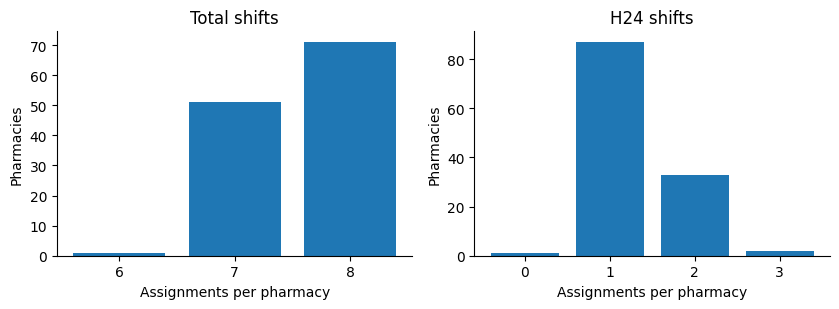

In [3]:
pharmacy_ids = pd.Index(sorted(schedule["pharmacy_id"].unique()), name="pharmacy_id")
pharmacy_profile = pd.DataFrame(index=pharmacy_ids)
pharmacy_profile["total_shifts"] = schedule.groupby("pharmacy_id").size().reindex(pharmacy_ids, fill_value=0)
pharmacy_profile["standard_shifts"] = schedule.loc[schedule["shift_type"].eq("STANDARD")].groupby("pharmacy_id").size().reindex(pharmacy_ids, fill_value=0)
pharmacy_profile["h24_shifts"] = schedule.loc[schedule["shift_type"].eq("H24")].groupby("pharmacy_id").size().reindex(pharmacy_ids, fill_value=0)



metrics = pd.DataFrame({
    "Total": fairness_metrics(pharmacy_profile["total_shifts"]),
    "STANDARD": fairness_metrics(pharmacy_profile["standard_shifts"]),
    "H24": fairness_metrics(pharmacy_profile["h24_shifts"]),
}).T
display(metrics.round(4))

fig, axes = plt.subplots(1, 2, figsize=(8.5, 3.2))
for axis, column, title in [(axes[0], "total_shifts", "Total shifts"), (axes[1], "h24_shifts", "H24 shifts")]:
    counts = pharmacy_profile[column].value_counts().sort_index()
    axis.bar(counts.index.astype(str), counts.values)
    axis.set_title(title)
    axis.set_xlabel("Assignments per pharmacy")
    axis.set_ylabel("Pharmacies")
    axis.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
plt.show()


## 4. Groups and P/C consistency


In [4]:
access_by_pharmacy = schedule.groupby("pharmacy_id")["access_mode"].first()
access_summary = access_by_pharmacy.value_counts().rename("pharmacies").to_frame()
access_summary["meaning"] = access_summary.index.map({"P": "open-door", "C": "call/closed-door"})
access_mode_changes = int(schedule.groupby("pharmacy_id")["access_mode"].nunique().gt(1).sum())
display(access_summary)

group_by_nt = weeks.groupby("nT")["rotation_group"].first().astype(int).to_dict()
rotation_groups = sorted(set(group_by_nt.values()))




group_frequency = schedule.groupby(["pharmacy_id", "rotation_group"]).size().rename("assignments").reset_index()
primary_group = (
    group_frequency.sort_values(["pharmacy_id", "assignments", "rotation_group"], ascending=[True, False, True])
    .drop_duplicates("pharmacy_id").set_index("pharmacy_id")["rotation_group"].astype(int)
)
group_sizes = primary_group.value_counts().sort_index().rename("pharmacies").to_frame()
display(group_sizes)



assigned_primary_group = schedule["pharmacy_id"].map(primary_group)
group_violations = schedule.loc[
    assigned_primary_group.ne(schedule["rotation_group"]),
    ["week_id", "nT", "rotation_group", "pharmacy_id", "shift_type"],
]
display(group_violations)
print("Rotation groups:", len(rotation_groups))
print("Pharmacies with any historical cross-group row:", group_violations["pharmacy_id"].nunique())
print("(carried into notebook 02 as candidates for secondary-group eligibility)")

require(access_mode_changes == 0, "Time-varying access mode requires explicit modeling.")


Rotation groups: 7
Pharmacies with any historical cross-group row: 1
(carried into notebook 02 as candidates for secondary-group eligibility)


,pharmacies,meaning
access_mode,,
P,118,open-door
C,5,call/closed-door


,pharmacies
rotation_group,
1,17
2,18
3,18
4,17
5,18
6,18
7,17


,week_id,nT,rotation_group,pharmacy_id,shift_type
475,2026-W28,21,7,P0076,H24


## 5. Export baseline evidence for notebook 02


In [5]:
maximum_historical_workload = int(pharmacy_profile["total_shifts"].max())

evidence = pd.DataFrame([
    ("Calendar weeks", len(weeks), "OBSERVED"),
    ("Maximum historical assignments", maximum_historical_workload, "OBSERVED (single-year sample, see section 5)"),
    ("Uniform rotating H24 per week", int(weekly_h24.iloc[0]) if weekly_h24.nunique() == 1 else None, "OBSERVED"),
    ("Same schedule for equal nT", f"{repeated_matches}/{repeated_pairs}", "OBSERVED"),
    ("Rotation groups", len(rotation_groups), "OBSERVED"),
    ("P/C changes", access_mode_changes, "OBSERVED DATA CONSISTENCY"),
    ("Weekly rotating staff", f"{weekly_total.min()}..{weekly_total.max()}", "OBSERVED STAFFING; NOT GEOGRAPHIC COVERAGE"),
    ("Historical cross-group rows", int(group_violations.shape[0]), "OBSERVED EXCEPTION -> secondary-eligibility candidates in NB02"),
    ("Geographic coverage", "not evaluated", "OUT OF SCOPE"),
], columns=["property", "evidence", "classification"])
display(evidence)

baseline_evidence = {
    "evidence_type": "baseline_derived_from_canonical_schedule",
    "canonical_file": canonical_path.name,
    "canonical_sha256": canonical_sha256,
    "derived_values": {
        "assignments": int(len(schedule)),
        "horizon_weeks": int(len(weeks)),
        "rotation_groups": [int(g) for g in rotation_groups],
        "group_by_nt": {str(int(nt)): int(g) for nt, g in group_by_nt.items()},
        "primary_group_by_pharmacy": {p: int(g) for p, g in primary_group.items()},
        "group_sizes": {str(int(g)): int(s) for g, s in group_sizes["pharmacies"].items()},
        "weekly_staffing_min": int(weekly_total.min()),
        "weekly_staffing_max": int(weekly_total.max()),
        "weekly_h24_uniform": bool(weekly_h24.nunique() == 1),
        "weekly_h24_value": int(weekly_h24.iloc[0]) if weekly_h24.nunique() == 1 else None,
        "maximum_annual_workload": maximum_historical_workload,
        "repeated_nt_matches": repeated_matches,
        "repeated_nt_pairs": repeated_pairs,
        "access_mode_changes": access_mode_changes,
        "cross_group_rows": int(group_violations.shape[0]),
        "cross_group_pharmacies": group_violations["pharmacy_id"].unique().tolist(),
        "single_year_sample_caveat": (
            "All parameters are derived from one 53-week cycle; no other year is available "
            "to test temporal stability. Treat as a working baseline, not a validated norm."
        ),
    },
}

Path("output/baseline_evidence.json").write_text(json.dumps(baseline_evidence, ensure_ascii=False, indent=2), encoding="utf-8")
evidence.to_csv("output/baseline_evidence.csv", index=False)
pharmacy_profile.reset_index().to_csv("output/baseline_pharmacy_profile.csv", index=False)
print("Saved: output/baseline_evidence.json, baseline_evidence.csv, baseline_pharmacy_profile.csv")

from validation import write_stage
write_stage(1, ['output/stage_00_manifest.json'], ['output/baseline_evidence.json', 'output/baseline_evidence.csv', 'output/baseline_pharmacy_profile.csv'])


Saved: output/baseline_evidence.json, baseline_evidence.csv, baseline_pharmacy_profile.csv


,property,evidence,classification
0,Calendar weeks,53,OBSERVED
1,Maximum historical assignments,8,"OBSERVED (single-year sample, see section 5)"
2,Uniform rotating H24 per week,3,OBSERVED
3,Same schedule for equal nT,11/11,OBSERVED
4,Rotation groups,7,OBSERVED
5,P/C changes,0,OBSERVED DATA CONSISTENCY
6,Weekly rotating staff,17..18,OBSERVED STAFFING; NOT GEOGRAPHIC COVERAGE
7,Historical cross-group rows,1,OBSERVED EXCEPTION -> secondary-eligibility ca...
8,Geographic coverage,not evaluated,OUT OF SCOPE
